In [1]:
import pandas as pd
import gzip
import os

DATA_DIR = '../data'

# Check all files are present and reasonable sizes
files = [
    'GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz',
    'GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt',
    'GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt',
    'refFlat.txt.gz',
]

for f in files:
    path = os.path.join(DATA_DIR, f)
    size_mb = os.path.getsize(path) / 1e6
    print(f'{f}\n  {size_mb:.1f} MB\n')

GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz
  1625.8 MB

GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt
  11.5 MB

GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt
  0.0 MB

refFlat.txt.gz
  8.0 MB



In [2]:
# Load sample attributes
samples = pd.read_csv(
    os.path.join(DATA_DIR, 'GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt'),
    sep='\t',
    usecols=['SAMPID', 'SMTSD', 'SMAFRZE']
)

# Load subject phenotypes
phenotypes = pd.read_csv(
    os.path.join(DATA_DIR, 'GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt'),
    sep='\t'
)

print("=== Sample Attributes ===")
print(f"Shape: {samples.shape}")
print(samples.head(3))
print()
print("=== Subject Phenotypes ===")
print(f"Shape: {phenotypes.shape}")
print(phenotypes.head(3))
print()
print("=== Columns in phenotypes ===")
print(phenotypes.columns.tolist())

=== Sample Attributes ===
Shape: (22951, 3)
                     SAMPID        SMTSD SMAFRZE
0  GTEX-1117F-0003-SM-58Q7G  Whole Blood     WES
1  GTEX-1117F-0003-SM-5DWSB  Whole Blood    OMNI
2  GTEX-1117F-0003-SM-6WBT7  Whole Blood     WGS

=== Subject Phenotypes ===
Shape: (980, 4)
       SUBJID  SEX    AGE  DTHHRDY
0  GTEX-1117F    2  60-69      4.0
1  GTEX-111CU    1  50-59      0.0
2  GTEX-111FC    1  60-69      1.0

=== Columns in phenotypes ===
['SUBJID', 'SEX', 'AGE', 'DTHHRDY']


In [3]:
# Extract subject ID from sample ID
samples['SUBJID'] = samples['SAMPID'].str.extract(r'(GTEX-[^-]+)')

# Keep only RNA-seq samples
rnaseq_samples = samples[samples['SMAFRZE'] == 'RNASEQ'].copy()

# Merge with phenotypes
meta = rnaseq_samples.merge(phenotypes[['SUBJID', 'SEX', 'AGE']], on='SUBJID', how='left')

# Convert age range string to midpoint integer
def age_to_midpoint(age_str):
    low, high = age_str.split('-')
    return (int(low) + int(high)) / 2

meta['AGE_MID'] = meta['AGE'].apply(age_to_midpoint)

print(f"RNA-seq samples: {len(meta)}")
print(f"Unique donors:   {meta['SUBJID'].nunique()}")
print(f"Unique tissues:  {meta['SMTSD'].nunique()}")
print()
print("Age distribution:")
print(meta['AGE'].value_counts().sort_index())
print()
print("Sample counts per tissue (top 10):")
print(meta['SMTSD'].value_counts().head(10))

RNA-seq samples: 17382
Unique donors:   948
Unique tissues:  54

Age distribution:
AGE
20-29    1320
30-39    1323
40-49    2702
50-59    5615
60-69    5821
70-79     601
Name: count, dtype: int64

Sample counts per tissue (top 10):
SMTSD
Muscle - Skeletal                      803
Whole Blood                            755
Skin - Sun Exposed (Lower leg)         701
Adipose - Subcutaneous                 663
Artery - Tibial                        663
Thyroid                                653
Nerve - Tibial                         619
Skin - Not Sun Exposed (Suprapubic)    604
Lung                                   578
Esophagus - Mucosa                     555
Name: count, dtype: int64


In [4]:
# Define genes of interest
RDNA_GENES = [
    # Pol I transcription machinery
    'UBTF', 'RRN3', 'POLR1A', 'POLR1B', 'TAF1A', 'TAF1C', 'TAF1D',
    # rRNA processing
    'NOP56', 'NOP58', 'BYSL', 'WDR12', 'WDR43', 'FCF1',
    # Nucleolar integrity
    'NPM1', 'NCL', 'FBL',
]

TELOMERE_GENES = [
    # Shelterin complex
    'TERF1', 'TERF2', 'TERF2IP', 'TINF2', 'POT1', 'ACD',
    # Telomerase
    'TERT',
    # CST complex
    'CTC1', 'STN1', 'TEN1',
]

ALL_GENES = RDNA_GENES + TELOMERE_GENES

print(f"Looking for {len(ALL_GENES)} genes total")
print("Loading TPM file — this may take a few minutes...")

# Read in chunks, keeping only rows matching our genes
chunks = []
chunk_num = 0

for chunk in pd.read_csv(
    os.path.join(DATA_DIR, 'GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz'),
    sep='\t',
    skiprows=2,
    compression='gzip',
    chunksize=500,
    low_memory=False
):
    mask = chunk['Description'].isin(ALL_GENES)
    if mask.any():
        chunks.append(chunk[mask])
    chunk_num += 1
    if chunk_num % 50 == 0:
        print(f"  ...processed {chunk_num * 500} genes")

tpm = pd.concat(chunks)
tpm = tpm.set_index('Description').drop(columns=['Name'])

print(f"\nDone! Loaded {tpm.shape[0]} genes x {tpm.shape[1]} samples")
print("\nGenes found:")
print(sorted(tpm.index.tolist()))
print("\nGenes NOT found:")
print(sorted(set(ALL_GENES) - set(tpm.index.tolist())))

Looking for 26 genes total
Loading TPM file — this may take a few minutes...
  ...processed 25000 genes
  ...processed 50000 genes

Done! Loaded 26 genes x 17382 samples

Genes found:
['ACD', 'BYSL', 'CTC1', 'FBL', 'FCF1', 'NCL', 'NOP56', 'NOP58', 'NPM1', 'POLR1A', 'POLR1B', 'POT1', 'RRN3', 'STN1', 'TAF1A', 'TAF1C', 'TAF1D', 'TEN1', 'TERF1', 'TERF2', 'TERF2IP', 'TERT', 'TINF2', 'UBTF', 'WDR12', 'WDR43']

Genes NOT found:
[]


In [5]:
# Transpose so samples are rows, genes are columns
tpm_t = tpm.T
tpm_t.index.name = 'SAMPID'
tpm_t = tpm_t.reset_index()

# Merge with metadata
df = tpm_t.merge(meta[['SAMPID', 'SUBJID', 'SMTSD', 'AGE', 'AGE_MID', 'SEX']], 
                 on='SAMPID', 
                 how='inner')

print(f"Combined dataframe shape: {df.shape}")
print(f"Samples with both expression and metadata: {len(df)}")
print()
print("Quick sanity check — mean TERT expression by age:")
print(df.groupby('AGE')['TERT'].mean().round(4))

Combined dataframe shape: (17382, 32)
Samples with both expression and metadata: 17382

Quick sanity check — mean TERT expression by age:
AGE
20-29    0.2089
30-39    0.1757
40-49    0.1625
50-59    0.1598
60-69    0.1484
70-79    0.1380
Name: TERT, dtype: float64


In [6]:
import numpy as np

# Compute scores as mean log-transformed TPM across each gene set
# use log1p (log(x+1)) to handle zeros and compress the dynamic range
# Then z-score each gene within tissue before averaging, so no single highly-expressed gene (like NPM1, NCL) dominates the score

# First log-transform the expression values
for gene in ALL_GENES:
    df[f'{gene}_log'] = np.log1p(df[gene])

log_rdna_genes = [f'{g}_log' for g in RDNA_GENES]
log_telo_genes = [f'{g}_log' for g in TELOMERE_GENES]

# Z-score within each tissue, then average across gene set
def make_score(dataframe, log_gene_cols, score_name):
    scored = dataframe.copy()
    # Z-score each gene globally
    zscores = scored[log_gene_cols].apply(
        lambda col: (col - col.mean()) / col.std(), axis=0
    )
    scored[score_name] = zscores.mean(axis=1)
    return scored

df = make_score(df, log_rdna_genes, 'rDNA_score')
df = make_score(df, log_telo_genes, 'Telo_score')

print("Scores added. Summary statistics:")
print(df[['rDNA_score', 'Telo_score']].describe().round(3))
print()
print("Mean scores by age group:")
print(df.groupby('AGE')[['rDNA_score', 'Telo_score']].mean().round(3))

Scores added. Summary statistics:
       rDNA_score  Telo_score
count   17382.000   17382.000
mean        0.000       0.000
std         0.875       0.717
min        -3.925      -3.434
25%        -0.464      -0.369
50%         0.210       0.172
75%         0.567       0.507
max         2.251       1.603

Mean scores by age group:
       rDNA_score  Telo_score
AGE                          
20-29       0.202       0.100
30-39       0.114       0.066
40-49       0.100       0.043
50-59       0.007       0.001
60-69      -0.113      -0.054
70-79      -0.123      -0.039


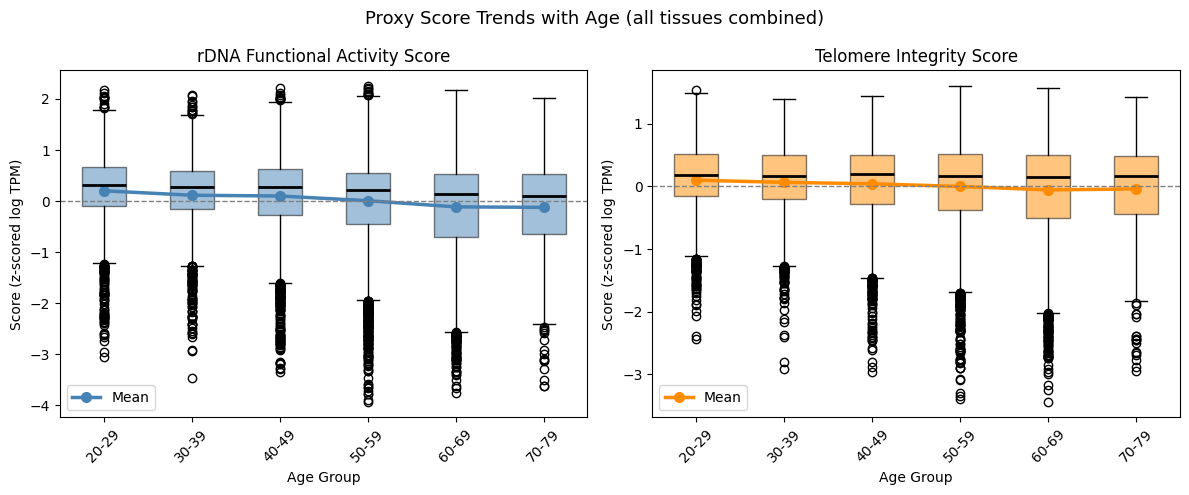

Saved to results/proxy_scores_by_age.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age midpoints for x-axis
age_order = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
age_mids = [25, 35, 45, 55, 65, 75]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Proxy Score Trends with Age (all tissues combined)', fontsize=13)

for ax, score, color, title in zip(
    axes,
    ['rDNA_score', 'Telo_score'],
    ['steelblue', 'darkorange'],
    ['rDNA Functional Activity Score', 'Telomere Integrity Score']
):
    # Plot individual sample distributions as boxplots
    data_by_age = [df[df['AGE'] == a][score].values for a in age_order]
    bp = ax.boxplot(data_by_age, patch_artist=True, 
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    
    # Overlay mean trend line
    means = [df[df['AGE'] == a][score].mean() for a in age_order]
    ax.plot(range(1, 7), means, 'o-', color=color, linewidth=2.5, 
            markersize=7, label='Mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    ax.set_xticks(range(1, 7))
    ax.set_xticklabels(age_order, rotation=45)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Score (z-scored log TPM)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('../results/proxy_scores_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/proxy_scores_by_age.png")

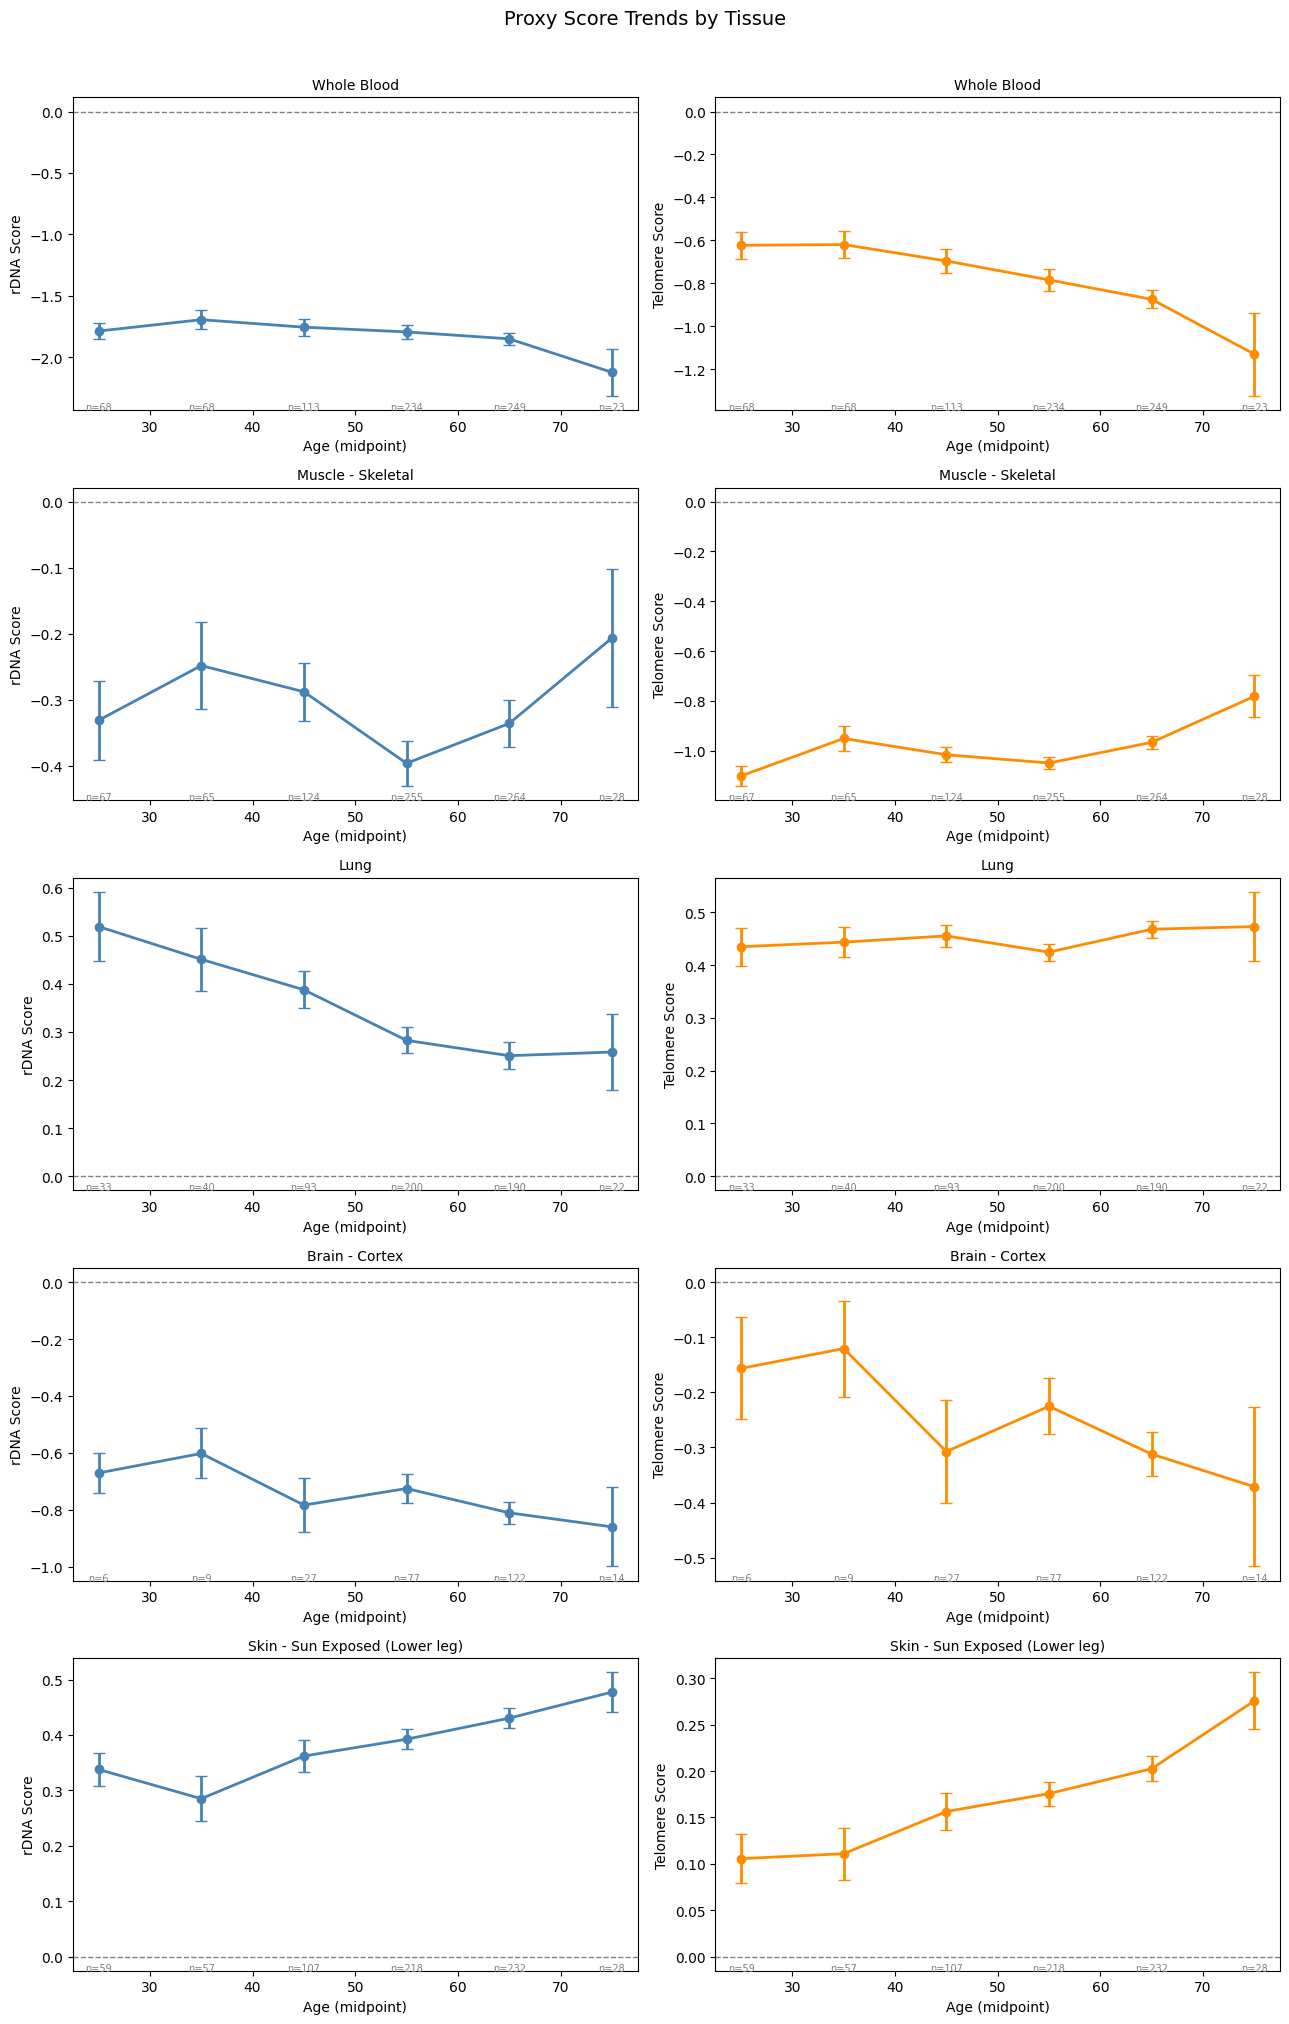

Saved to results/proxy_scores_by_tissue.png


In [8]:
tissues_of_interest = [
    'Whole Blood',
    'Muscle - Skeletal', 
    'Lung',
    'Brain - Cortex',
    'Skin - Sun Exposed (Lower leg)',
]

fig, axes = plt.subplots(len(tissues_of_interest), 2, 
                          figsize=(13, 4 * len(tissues_of_interest)))
fig.suptitle('Proxy Score Trends by Tissue', fontsize=14, y=1.01)

for row, tissue in enumerate(tissues_of_interest):
    tdf = df[df['SMTSD'] == tissue]
    
    for col, (score, color, label) in enumerate([
        ('rDNA_score', 'steelblue', 'rDNA Score'),
        ('Telo_score', 'darkorange', 'Telomere Score'),
    ]):
        ax = axes[row, col]
        means = [tdf[tdf['AGE'] == a][score].mean() for a in age_order]
        sems  = [tdf[tdf['AGE'] == a][score].sem()  for a in age_order]
        ns    = [len(tdf[tdf['AGE'] == a]) for a in age_order]
        
        ax.errorbar(age_mids, means, yerr=sems, fmt='o-', 
                    color=color, linewidth=2, markersize=6, capsize=4)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_title(f'{tissue}', fontsize=10)
        ax.set_xlabel('Age (midpoint)')
        ax.set_ylabel(label)
        
        # Annotate with sample sizes
        for x, n in zip(age_mids, ns):
            ax.annotate(f'n={n}', (x, ax.get_ylim()[0]), 
                        ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('../results/proxy_scores_by_tissue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/proxy_scores_by_tissue.png")

In [9]:
from scipy import stats

results = []

for tissue in sorted(df['SMTSD'].unique()):
    tdf = df[df['SMTSD'] == tissue]
    n = len(tdf)
    if n < 30:  # skip tissues with very few samples
        continue
    
    for score in ['rDNA_score', 'Telo_score']:
        r, p = stats.spearmanr(tdf['AGE_MID'], tdf[score])
        results.append({
            'tissue': tissue,
            'score': score,
            'n': n,
            'spearman_r': round(r, 3),
            'p_value': round(p, 4),
            'significant': p < 0.05
        })

corr_df = pd.DataFrame(results)

# Summary
print("=== Tissues with significant negative correlation (predicted by TRCS) ===")
for score in ['rDNA_score', 'Telo_score']:
    sig_neg = corr_df[
        (corr_df['score'] == score) & 
        (corr_df['significant']) & 
        (corr_df['spearman_r'] < 0)
    ]
    print(f"\n{score}: {len(sig_neg)} tissues")
    print(sig_neg[['tissue', 'n', 'spearman_r', 'p_value']].sort_values('spearman_r').to_string(index=False))

print("\n=== Tissues with significant POSITIVE correlation (against TRCS) ===")
for score in ['rDNA_score', 'Telo_score']:
    sig_pos = corr_df[
        (corr_df['score'] == score) & 
        (corr_df['significant']) & 
        (corr_df['spearman_r'] > 0)
    ]
    print(f"\n{score}: {len(sig_pos)} tissues")
    print(sig_pos[['tissue', 'n', 'spearman_r', 'p_value']].sort_values('spearman_r', ascending=False).to_string(index=False))

=== Tissues with significant negative correlation (predicted by TRCS) ===

rDNA_score: 16 tissues
                                   tissue   n  spearman_r  p_value
                                  Stomach 359      -0.223   0.0000
         Small Intestine - Terminal Ileum 187      -0.219   0.0026
            Brain - Cerebellar Hemisphere 215      -0.213   0.0017
                                    Ovary 180      -0.201   0.0068
                   Heart - Left Ventricle 432      -0.195   0.0000
                     Brain - Hypothalamus 202      -0.194   0.0057
                       Brain - Cerebellum 241      -0.191   0.0028
                 Brain - Substantia nigra 139      -0.188   0.0270
                                     Lung 578      -0.182   0.0000
             Brain - Frontal Cortex (BA9) 209      -0.176   0.0107
                           Artery - Aorta 432      -0.163   0.0007
Brain - Nucleus accumbens (basal ganglia) 246      -0.152   0.0167
                          Colon

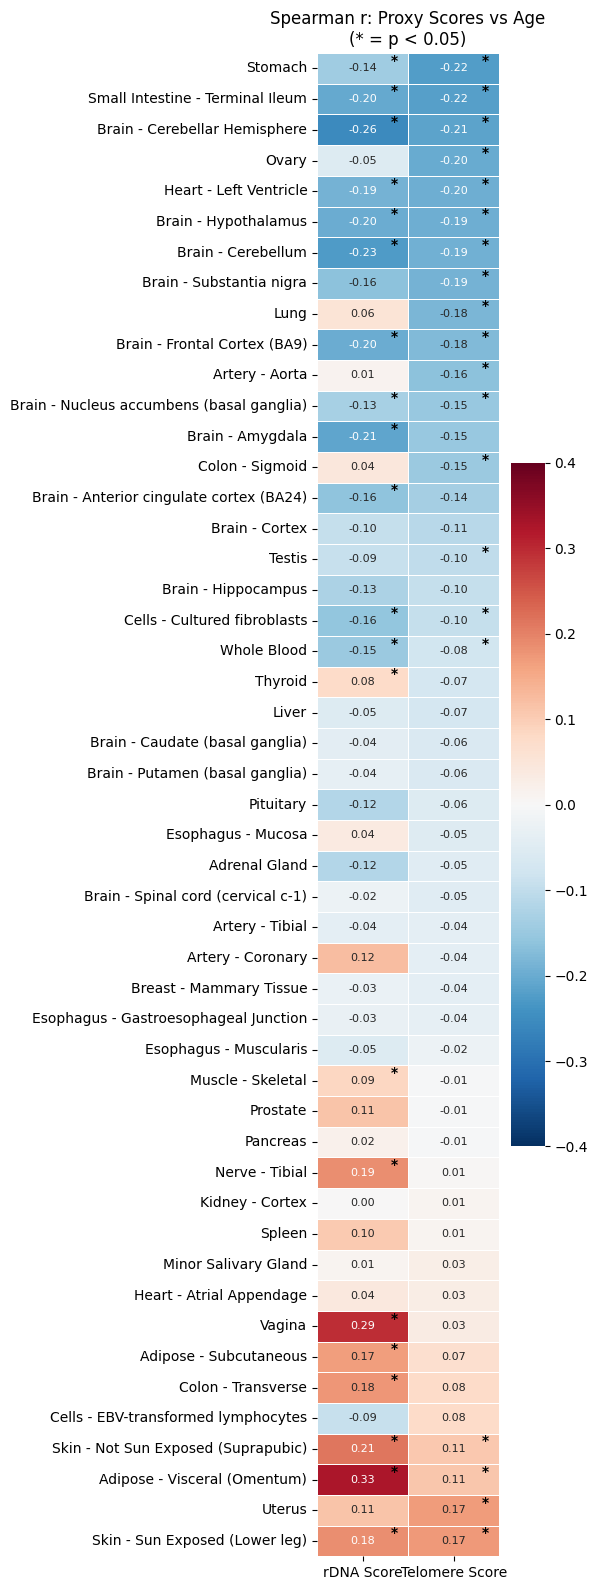

Saved to results/correlation_heatmap.png


In [10]:
# Save correlation results
corr_df.to_csv('../results/spearman_correlations.csv', index=False)

# Pivot for heatmap
heatmap_data = corr_df.pivot(index='tissue', columns='score', values='spearman_r')
sig_mask = corr_df.pivot(index='tissue', columns='score', values='significant')

# Sort by rDNA score
heatmap_data = heatmap_data.sort_values('rDNA_score')

fig, ax = plt.subplots(figsize=(6, 16))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-0.4, vmax=0.4,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8}
)

# Mark significant cells with asterisk
for i, tissue in enumerate(heatmap_data.index):
    for j, score in enumerate(heatmap_data.columns):
        if sig_mask.loc[tissue, score]:
            ax.text(j + 0.85, i + 0.25, '*', 
                    ha='center', va='center', 
                    fontsize=10, color='black', fontweight='bold')

ax.set_title('Spearman r: Proxy Scores vs Age\n(* = p < 0.05)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(['rDNA Score', 'Telomere Score'], rotation=0)

plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/correlation_heatmap.png")

In [11]:
import gseapy as gp

# Fetch MSigDB Hallmark gene sets
hallmarks = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

# Check the exact key name for P53
p53_keys = [k for k in hallmarks.keys() if 'P53' in k.upper()]
print("P53-related gene sets found:")
print(p53_keys)

p53_genes = hallmarks[p53_keys[0]]
print(f"\nP53 pathway contains {len(p53_genes)} genes")
print("First 10:", p53_genes[:10])

# Also grab competitor pathways
oxphos_keys = [k for k in hallmarks.keys() if 'OXIDATIVE' in k.upper()]
dna_repair_keys = [k for k in hallmarks.keys() if 'DNA_REPAIR' in k.upper() or 'DNA REPAIR' in k.upper()]
ros_keys = [k for k in hallmarks.keys() if 'REACTIVE' in k.upper()]

print(f"\nOxidative phosphorylation: {oxphos_keys}")
print(f"DNA repair: {dna_repair_keys}")
print(f"ROS pathway: {ros_keys}")

P53-related gene sets found:
['p53 Pathway']

P53 pathway contains 200 genes
First 10: ['CDKN1A', 'BTG2', 'MDM2', 'CCNG1', 'FAS', 'TOB1', 'GADD45A', 'PHLDA3', 'TAP1', 'CDKN2B']

Oxidative phosphorylation: ['Oxidative Phosphorylation']
DNA repair: ['DNA Repair']
ROS pathway: ['Reactive Oxygen Species Pathway']


In [12]:
# Collect all genes we need to load from the TPM file
p53_genes_set = set(hallmarks['p53 Pathway'])
oxphos_genes_set = set(hallmarks['Oxidative Phosphorylation'])
dna_repair_genes_set = set(hallmarks['DNA Repair'])
ros_genes_set = set(hallmarks['Reactive Oxygen Species Pathway'])

all_pathway_genes = p53_genes_set | oxphos_genes_set | dna_repair_genes_set | ros_genes_set

print(f"Total unique genes to load: {len(all_pathway_genes)}")
print(f"  P53 pathway:                {len(p53_genes_set)}")
print(f"  Oxidative phosphorylation:  {len(oxphos_genes_set)}")
print(f"  DNA repair:                 {len(dna_repair_genes_set)}")
print(f"  ROS pathway:                {len(ros_genes_set)}")

print("\nLoading pathway genes from TPM file — this will take a few minutes...")

chunks = []
chunk_num = 0

for chunk in pd.read_csv(
    os.path.join(DATA_DIR, 'GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz'),
    sep='\t',
    skiprows=2,
    compression='gzip',
    chunksize=500,
    low_memory=False
):
    mask = chunk['Description'].isin(all_pathway_genes)
    if mask.any():
        chunks.append(chunk[mask])
    chunk_num += 1
    if chunk_num % 50 == 0:
        print(f"  ...processed {chunk_num * 500} genes")

tpm_pathways = pd.concat(chunks)
tpm_pathways = tpm_pathways.set_index('Description').drop(columns=['Name'])

print(f"\nDone! Loaded {tpm_pathways.shape[0]} genes x {tpm_pathways.shape[1]} samples")
print(f"\nGenes found vs expected:")
print(f"  P53:    {len(p53_genes_set & set(tpm_pathways.index))} / {len(p53_genes_set)}")
print(f"  OxPhos: {len(oxphos_genes_set & set(tpm_pathways.index))} / {len(oxphos_genes_set)}")
print(f"  DNA:    {len(dna_repair_genes_set & set(tpm_pathways.index))} / {len(dna_repair_genes_set)}")
print(f"  ROS:    {len(ros_genes_set & set(tpm_pathways.index))} / {len(ros_genes_set)}")

Total unique genes to load: 576
  P53 pathway:                200
  Oxidative phosphorylation:  200
  DNA repair:                 150
  ROS pathway:                49

Loading pathway genes from TPM file — this will take a few minutes...
  ...processed 25000 genes
  ...processed 50000 genes

Done! Loaded 556 genes x 17382 samples

Genes found vs expected:
  P53:    195 / 200
  OxPhos: 185 / 200
  DNA:    149 / 150
  ROS:    49 / 49


In [13]:
# Transpose pathway TPM matrix
tpm_pathways_t = tpm_pathways.T
tpm_pathways_t.index.name = 'SAMPID'
tpm_pathways_t = tpm_pathways_t.reset_index()

# Merge with existing df
df_full = df.merge(tpm_pathways_t, on='SAMPID', how='inner')
print(f"Full dataframe shape: {df_full.shape}")

def make_pathway_score(dataframe, gene_set, score_name):
    genes_present = [g for g in gene_set if g in dataframe.columns]
    print(f"  {score_name}: using {len(genes_present)} / {len(gene_set)} genes")
    
    log_data = {}
    for g in genes_present:
        col = dataframe[g]
        # If duplicate columns exist, take the first one
        if isinstance(col, pd.DataFrame):
            col = col.iloc[:, 0]
        log_data[f'_log_{g}'] = np.log1p(col.values)
    
    # Build log df all at once
    log_df = pd.DataFrame(log_data, index=dataframe.index)
    
    # Z-score each gene then average
    zscored = log_df.apply(lambda c: (c - c.mean()) / c.std(), axis=0)
    dataframe[score_name] = zscored.mean(axis=1)
    
    return dataframe

print("Building pathway scores...")
df_full = make_pathway_score(df_full, p53_genes_set,        'P53_score')
df_full = make_pathway_score(df_full, oxphos_genes_set,     'OxPhos_score')
df_full = make_pathway_score(df_full, dna_repair_genes_set, 'DNA_repair_score')
df_full = make_pathway_score(df_full, ros_genes_set,        'ROS_score')

print("\nAll scores built. Summary:")
score_cols = ['rDNA_score', 'Telo_score', 'P53_score', 
              'OxPhos_score', 'DNA_repair_score', 'ROS_score']
print(df_full[score_cols].describe().round(3))

Full dataframe shape: (17382, 616)
Building pathway scores...
  P53_score: using 195 / 200 genes
  OxPhos_score: using 185 / 200 genes
  DNA_repair_score: using 148 / 150 genes
  ROS_score: using 49 / 49 genes

All scores built. Summary:
       rDNA_score  Telo_score  P53_score  OxPhos_score  DNA_repair_score  \
count   17382.000   17382.000  17382.000     17382.000         17382.000   
mean        0.000       0.000     -0.000         0.000            -0.000   
std         0.875       0.717      0.536         0.693             0.696   
min        -3.925      -3.434     -2.475        -4.511            -3.676   
25%        -0.464      -0.369     -0.358        -0.132            -0.365   
50%         0.210       0.172      0.150         0.168             0.198   
75%         0.567       0.507      0.411         0.387             0.471   
max         2.251       1.603      0.995         1.514             1.362   

       ROS_score  
count  17382.000  
mean       0.000  
std        0.527  
m

In [14]:
import statsmodels.formula.api as smf

tissues_to_test = sorted(df_full['SMTSD'].unique())
regression_results = []

for tissue in tissues_to_test:
    tdf = df_full[df_full['SMTSD'] == tissue].copy()
    n = len(tdf)
    if n < 30:
        continue

    # Fit four models per tissue:
    # Model A: P53 ~ rDNA only (+ age + sex as covariates)
    # Model B: P53 ~ Telo only (+ age + sex)
    # Model C: P53 ~ rDNA + Telo (+ age + sex)  — the TRCS model
    # Models D/E/F: same structure but with competitor pathway scores as outcome

    for outcome, outcome_label in [
        ('P53_score',        'P53'),
        ('OxPhos_score',     'OxPhos'),
        ('DNA_repair_score', 'DNA_repair'),
        ('ROS_score',        'ROS'),
    ]:
        try:
            mA = smf.ols(f'{outcome} ~ rDNA_score + AGE_MID + SEX', data=tdf).fit()
            mB = smf.ols(f'{outcome} ~ Telo_score + AGE_MID + SEX', data=tdf).fit()
            mC = smf.ols(f'{outcome} ~ rDNA_score + Telo_score + AGE_MID + SEX', data=tdf).fit()

            regression_results.append({
                'tissue':         tissue,
                'n':              n,
                'outcome':        outcome_label,
                # R-squared for each model
                'r2_A_rDNA':      mA.rsquared,
                'r2_B_Telo':      mB.rsquared,
                'r2_C_both':      mC.rsquared,
                # Coefficients for rDNA and Telo in combined model
                'coef_rDNA':      mC.params.get('rDNA_score', np.nan),
                'coef_Telo':      mC.params.get('Telo_score', np.nan),
                'pval_rDNA':      mC.pvalues.get('rDNA_score', np.nan),
                'pval_Telo':      mC.pvalues.get('Telo_score', np.nan),
                # Does combined model beat individual models?
                'r2_gain_over_A': mC.rsquared - mA.rsquared,
                'r2_gain_over_B': mC.rsquared - mB.rsquared,
            })
        except Exception as e:
            print(f"  Skipped {tissue} / {outcome_label}: {e}")

reg_df = pd.DataFrame(regression_results)
reg_df.to_csv('../results/regression_results.csv', index=False)
print(f"Ran {len(reg_df)} models across {reg_df['tissue'].nunique()} tissues")
print()

# Focus on P53 outcome first
p53_reg = reg_df[reg_df['outcome'] == 'P53'].copy()
print("=== Model C (rDNA + Telo) R² for P53 outcome, top 15 tissues ===")
print(p53_reg[['tissue', 'n', 'r2_A_rDNA', 'r2_B_Telo', 'r2_C_both']]
      .sort_values('r2_C_both', ascending=False)
      .head(15)
      .round(3)
      .to_string(index=False))

Ran 196 models across 49 tissues

=== Model C (rDNA + Telo) R² for P53 outcome, top 15 tissues ===
                                   tissue   n  r2_A_rDNA  r2_B_Telo  r2_C_both
                          Kidney - Cortex  85      0.940      0.970      0.973
                   Heart - Left Ventricle 432      0.924      0.967      0.969
                      Brain - Hippocampus 197      0.952      0.948      0.960
          Brain - Putamen (basal ganglia) 205      0.957      0.947      0.960
                         Brain - Amygdala 152      0.938      0.921      0.954
Brain - Nucleus accumbens (basal ganglia) 246      0.947      0.936      0.951
                     Brain - Hypothalamus 202      0.946      0.923      0.949
                                 Pancreas 328      0.855      0.945      0.947
                 Brain - Substantia nigra 139      0.932      0.895      0.945
          Brain - Caudate (basal ganglia) 246      0.933      0.930      0.939
                              Wh

In [15]:
# The high R² is likely driven by tissue-level co-expression
# Fix: residualize all scores against tissue mean
# This removes between-tissue variation and focuses on within-tissue age effects

print("Residualizing scores within tissue...")

score_cols = ['rDNA_score', 'Telo_score', 'P53_score', 
              'OxPhos_score', 'DNA_repair_score', 'ROS_score']

df_resid = df_full.copy()

for score in score_cols:
    # Subtract tissue mean and divide by tissue std
    tissue_mean = df_resid.groupby('SMTSD')[score].transform('mean')
    tissue_std  = df_resid.groupby('SMTSD')[score].transform('std')
    df_resid[f'{score}_resid'] = (df_resid[score] - tissue_mean) / tissue_std

resid_cols = [f'{s}_resid' for s in score_cols]
print("Done. Residualized score summary:")
print(df_resid[resid_cols].describe().round(3))

Residualizing scores within tissue...
Done. Residualized score summary:
       rDNA_score_resid  Telo_score_resid  P53_score_resid  \
count         17382.000         17382.000        17382.000   
mean             -0.000            -0.000            0.000   
std               0.998             0.998            0.998   
min              -5.953            -7.924           -7.523   
25%              -0.619            -0.602           -0.610   
50%               0.047             0.081            0.059   
75%               0.649             0.681            0.665   
max               4.814             3.916            4.161   

       OxPhos_score_resid  DNA_repair_score_resid  ROS_score_resid  
count           17382.000               17382.000        17382.000  
mean                0.000                  -0.000           -0.000  
std                 0.998                   0.998            0.998  
min                -7.920                  -7.308           -6.137  
25%                -0.56

In [16]:
regression_results_resid = []

for tissue in sorted(df_resid['SMTSD'].unique()):
    tdf = df_resid[df_resid['SMTSD'] == tissue].copy()
    n = len(tdf)
    if n < 30:
        continue

    for outcome, outcome_label in [
        ('P53_score_resid',        'P53'),
        ('OxPhos_score_resid',     'OxPhos'),
        ('DNA_repair_score_resid', 'DNA_repair'),
        ('ROS_score_resid',        'ROS'),
    ]:
        try:
            mA = smf.ols(f'{outcome} ~ rDNA_score_resid + AGE_MID + SEX', data=tdf).fit()
            mB = smf.ols(f'{outcome} ~ Telo_score_resid + AGE_MID + SEX', data=tdf).fit()
            mC = smf.ols(f'{outcome} ~ rDNA_score_resid + Telo_score_resid + AGE_MID + SEX', data=tdf).fit()

            regression_results_resid.append({
                'tissue':         tissue,
                'n':              n,
                'outcome':        outcome_label,
                'r2_A_rDNA':      mA.rsquared,
                'r2_B_Telo':      mB.rsquared,
                'r2_C_both':      mC.rsquared,
                'coef_rDNA':      mC.params.get('rDNA_score_resid', np.nan),
                'coef_Telo':      mC.params.get('Telo_score_resid', np.nan),
                'pval_rDNA':      mC.pvalues.get('rDNA_score_resid', np.nan),
                'pval_Telo':      mC.pvalues.get('Telo_score_resid', np.nan),
                'r2_gain_over_A': mC.rsquared - mA.rsquared,
                'r2_gain_over_B': mC.rsquared - mB.rsquared,
            })
        except Exception as e:
            print(f"  Skipped {tissue} / {outcome_label}: {e}")

reg_resid_df = pd.DataFrame(regression_results_resid)
reg_resid_df.to_csv('../results/regression_results_residualized.csv', index=False)

print(f"Ran {len(reg_resid_df)} models across {reg_resid_df['tissue'].nunique()} tissues")
print()

# P53 outcome summary
p53_resid = reg_resid_df[reg_resid_df['outcome'] == 'P53'].copy()

print("=== Model R² for P53 outcome (residualized), top 15 tissues ===")
print(p53_resid[['tissue', 'n', 'r2_A_rDNA', 'r2_B_Telo', 'r2_C_both']]
      .sort_values('r2_C_both', ascending=False)
      .head(15)
      .round(3)
      .to_string(index=False))

print()
print("=== How often does Model C beat both A and B? ===")
both_beat = p53_resid[
    (p53_resid['r2_gain_over_A'] > 0.005) & 
    (p53_resid['r2_gain_over_B'] > 0.005)
]
print(f"{len(both_beat)} / {len(p53_resid)} tissues show meaningful R² gain from combining both scores")

Ran 196 models across 49 tissues

=== Model R² for P53 outcome (residualized), top 15 tissues ===
                                   tissue   n  r2_A_rDNA  r2_B_Telo  r2_C_both
                          Kidney - Cortex  85      0.940      0.970      0.973
                   Heart - Left Ventricle 432      0.924      0.967      0.969
                      Brain - Hippocampus 197      0.952      0.948      0.960
          Brain - Putamen (basal ganglia) 205      0.957      0.947      0.960
                         Brain - Amygdala 152      0.938      0.921      0.954
Brain - Nucleus accumbens (basal ganglia) 246      0.947      0.936      0.951
                     Brain - Hypothalamus 202      0.946      0.923      0.949
                                 Pancreas 328      0.855      0.945      0.947
                 Brain - Substantia nigra 139      0.932      0.895      0.945
          Brain - Caudate (basal ganglia) 246      0.933      0.930      0.939
                              Who

=== Correlation matrix of residualized scores (all samples) ===
                        rDNA_score_resid  Telo_score_resid  P53_score_resid  \
rDNA_score_resid                   1.000             0.738            0.699   
Telo_score_resid                   0.738             1.000            0.817   
P53_score_resid                    0.699             0.817            1.000   
OxPhos_score_resid                 0.623             0.610            0.555   
DNA_repair_score_resid             0.827             0.872            0.810   
ROS_score_resid                    0.734             0.671            0.747   

                        OxPhos_score_resid  DNA_repair_score_resid  \
rDNA_score_resid                     0.623                   0.827   
Telo_score_resid                     0.610                   0.872   
P53_score_resid                      0.555                   0.810   
OxPhos_score_resid                   1.000                   0.789   
DNA_repair_score_resid          

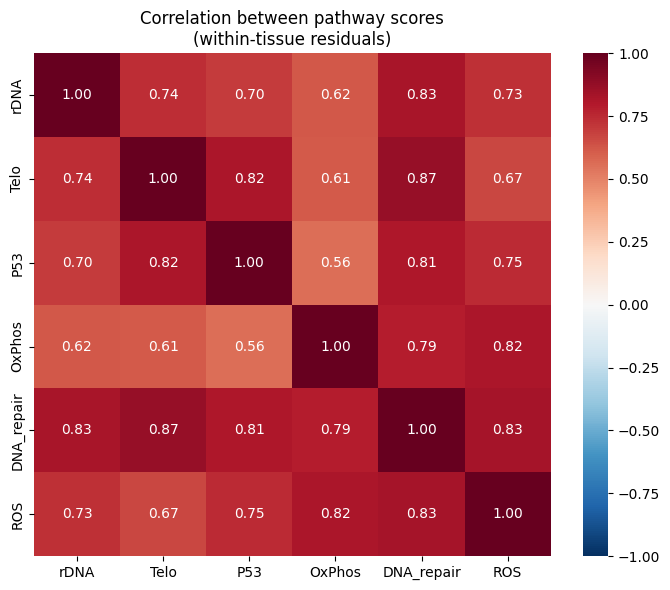

In [17]:
# The collinearity problem: all pathway scores are driven by a shared
# "transcriptional activity" factor within each sample.
# Solution: check the actual correlation structure first

print("=== Correlation matrix of residualized scores (all samples) ===")
corr_matrix = df_resid[resid_cols].corr().round(3)
print(corr_matrix)
print()

# Visualize
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    xticklabels=[s.replace('_score_resid', '') for s in resid_cols],
    yticklabels=[s.replace('_score_resid', '') for s in resid_cols],
)
ax.set_title('Correlation between pathway scores\n(within-tissue residuals)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/score_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# Extract PC1 from all six scores
pca = PCA(n_components=1)
pc1 = pca.fit_transform(df_resid[resid_cols])
df_resid['PC1'] = pc1[:, 0]

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance across all scores")
print()
print("PC1 loadings (how much each score contributes):")
for score, loading in zip(resid_cols, pca.components_[0]):
    print(f"  {score.replace('_score_resid',''):12s}  {loading:.3f}")

# Now residualize each score against PC1
# What remains is score-specific variance, independent of global activity
print()
print("Residualizing scores against PC1...")
for score in resid_cols:
    model = smf.ols(f'{score} ~ PC1', data=df_resid).fit()
    df_resid[f'{score}_pc1resid'] = model.resid

pc1resid_cols = [f'{s}_pc1resid' for s in resid_cols]
print("Done. Variance remaining after PC1 removal:")
for col in pc1resid_cols:
    print(f"  {col.replace('_score_resid_pc1resid',''):12s}  std = {df_resid[col].std():.3f}")

PC1 explains 78.7% of variance across all scores

PC1 loadings (how much each score contributes):
  rDNA          0.400
  Telo          0.408
  P53           0.401
  OxPhos        0.379
  DNA_repair    0.444
  ROS           0.415

Residualizing scores against PC1...
Done. Variance remaining after PC1 removal:
  rDNA          std = 0.494
  Telo          std = 0.461
  P53           std = 0.490
  OxPhos        std = 0.566
  DNA_repair    std = 0.260
  ROS           std = 0.431


In [19]:
from sklearn.decomposition import PCA

results_partial = []

for tissue in sorted(df_resid['SMTSD'].unique()):
    tdf = df_resid[df_resid['SMTSD'] == tissue].copy()
    n = len(tdf)
    if n < 30:
        continue

    # Partial correlations: does rDNA or Telo predict P53 uniquely
    # after removing shared transcriptional activity?
    p53_clean    = tdf['P53_score_resid_pc1resid']
    rdna_clean   = tdf['rDNA_score_resid_pc1resid']
    telo_clean   = tdf['Telo_score_resid_pc1resid']
    oxphos_clean = tdf['OxPhos_score_resid_pc1resid']
    dna_clean    = tdf['DNA_repair_score_resid_pc1resid']
    ros_clean    = tdf['ROS_score_resid_pc1resid']

    def safe_spearman(a, b):
        if a.std() < 1e-10 or b.std() < 1e-10:
            return np.nan, np.nan
        return spearmanr(a, b)

    r_rdna,   p_rdna   = safe_spearman(rdna_clean,   p53_clean)
    r_telo,   p_telo   = safe_spearman(telo_clean,   p53_clean)
    r_oxphos, p_oxphos = safe_spearman(oxphos_clean, p53_clean)
    r_dna,    p_dna    = safe_spearman(dna_clean,    p53_clean)
    r_ros,    p_ros    = safe_spearman(ros_clean,     p53_clean)

    # Also correlate each predictor with age
    age_vals = tdf['AGE_MID']
    r_rdna_age, _ = safe_spearman(rdna_clean, age_vals)
    r_telo_age, _ = safe_spearman(telo_clean, age_vals)
    r_p53_age,  _ = safe_spearman(p53_clean,  age_vals)

    results_partial.append({
        'tissue':       tissue,
        'n':            n,
        # Partial r with P53
        'r_rDNA_P53':   r_rdna,
        'p_rDNA_P53':   p_rdna,
        'r_Telo_P53':   r_telo,
        'p_Telo_P53':   p_telo,
        'r_OxPhos_P53': r_oxphos,
        'p_OxPhos_P53': p_oxphos,
        'r_DNA_P53':    r_dna,
        'p_DNA_P53':    p_dna,
        'r_ROS_P53':    r_ros,
        'p_ROS_P53':    p_ros,
        # Each predictor vs age
        'r_rDNA_age':   r_rdna_age,
        'r_Telo_age':   r_telo_age,
        'r_P53_age':    r_p53_age,
    })

partial_df = pd.DataFrame(results_partial)
partial_df.to_csv('../results/partial_correlations.csv', index=False)

print(f"Computed partial correlations for {len(partial_df)} tissues")
print()

# Summary: how many tissues show significant partial correlation
alpha = 0.05
for predictor, r_col, p_col in [
    ('rDNA',    'r_rDNA_P53',   'p_rDNA_P53'),
    ('Telo',    'r_Telo_P53',   'p_Telo_P53'),
    ('OxPhos',  'r_OxPhos_P53', 'p_OxPhos_P53'),
    ('DNA_rep', 'r_DNA_P53',    'p_DNA_P53'),
    ('ROS',     'r_ROS_P53',    'p_ROS_P53'),
]:
    sig = partial_df[partial_df[p_col] < alpha]
    pos = sig[sig[r_col] > 0]
    neg = sig[sig[r_col] < 0]
    print(f"{predictor:10s}  significant in {len(sig):2d}/49 tissues  "
          f"({len(pos)} positive, {len(neg)} negative)")

print()
print("=== Top tissues: rDNA partial correlation with P53 ===")
print(partial_df[['tissue', 'n', 'r_rDNA_P53', 'p_rDNA_P53']]
      .sort_values('r_rDNA_P53', ascending=False)
      .head(10)
      .round(3)
      .to_string(index=False))

Computed partial correlations for 49 tissues

rDNA        significant in 36/49 tissues  (10 positive, 26 negative)
Telo        significant in 37/49 tissues  (19 positive, 18 negative)
OxPhos      significant in 49/49 tissues  (0 positive, 49 negative)
DNA_rep     significant in 38/49 tissues  (9 positive, 29 negative)
ROS         significant in 29/49 tissues  (8 positive, 21 negative)

=== Top tissues: rDNA partial correlation with P53 ===
                  tissue   n  r_rDNA_P53  p_rDNA_P53
         Kidney - Cortex  85       0.438       0.000
        Brain - Amygdala 152       0.351       0.000
     Brain - Hippocampus 197       0.347       0.000
Brain - Substantia nigra 139       0.296       0.000
             Whole Blood 755       0.188       0.000
 Breast - Mammary Tissue 459       0.171       0.000
  Heart - Left Ventricle 432       0.156       0.001
    Brain - Hypothalamus 202       0.155       0.028
       Muscle - Skeletal 803       0.134       0.000
Heart - Atrial Appendage 4

                                       tissue    n  r_rDNA_P53    p_rDNA_P53  \
0                      Adipose - Subcutaneous  663   -0.208091  6.399096e-08   
1                Adipose - Visceral (Omentum)  541   -0.263957  4.482550e-10   
2                               Adrenal Gland  258   -0.085037  1.732837e-01   
3                              Artery - Aorta  432   -0.289495  8.712295e-10   
4                           Artery - Coronary  240   -0.230351  3.200980e-04   
5                             Artery - Tibial  663   -0.080226  3.890788e-02   
6                            Brain - Amygdala  152    0.351209  9.147297e-06   
7    Brain - Anterior cingulate cortex (BA24)  176    0.095551  2.071330e-01   
8             Brain - Caudate (basal ganglia)  246   -0.011356  8.593458e-01   
9               Brain - Cerebellar Hemisphere  215   -0.218799  1.243400e-03   
10                         Brain - Cerebellum  241   -0.532015  5.171261e-19   
11                             Brain - C

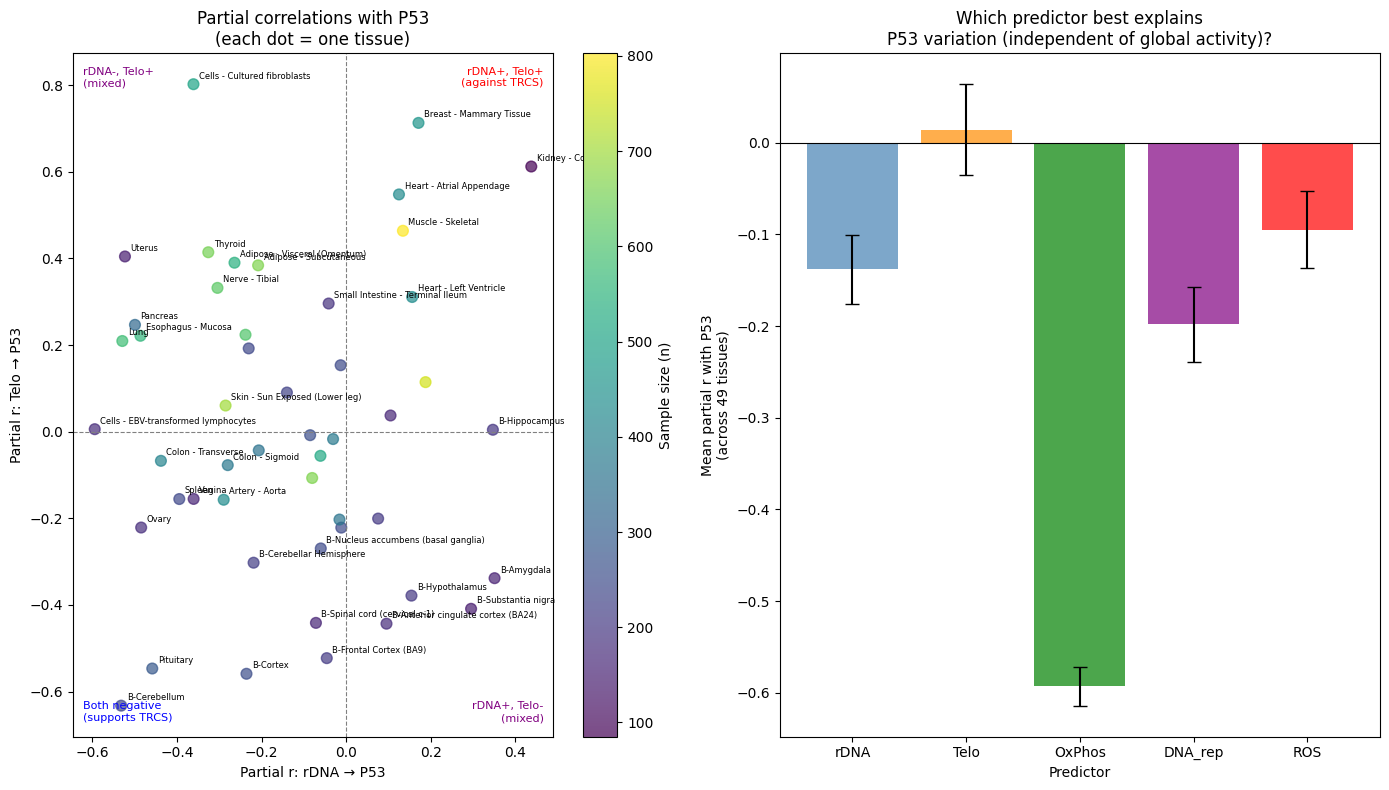

Saved to results/partial_correlation_summary.png


In [26]:
print(partial_df)
# print(partial_df['r_Telo_P53'])
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left panel: partial r with P53 for rDNA and Telo, one dot per tissue
ax = axes[0]
sc = ax.scatter(
    partial_df['r_rDNA_P53'],
    partial_df['r_Telo_P53'],
    c=partial_df['n'],
    cmap='viridis',
    alpha=0.7,
    s=60
)
plt.colorbar(sc, ax=ax, label='Sample size (n)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Partial r: rDNA → P53')
ax.set_ylabel('Partial r: Telo → P53')
ax.set_title('Partial correlations with P53\n(each dot = one tissue)')

# Annotate quadrants
ax.text(0.02, 0.98, 'rDNA-, Telo+\n(mixed)', transform=ax.transAxes,
        va='top', fontsize=8, color='purple')
ax.text(0.98, 0.98, 'rDNA+, Telo+\n(against TRCS)', transform=ax.transAxes,
        va='top', ha='right', fontsize=8, color='red')
ax.text(0.02, 0.02, 'Both negative\n(supports TRCS)', transform=ax.transAxes,
        va='bottom', fontsize=8, color='blue')
ax.text(0.98, 0.02, 'rDNA+, Telo-\n(mixed)', transform=ax.transAxes,
        va='bottom', ha='right', fontsize=8, color='purple')

# Label a few key tissues
for _, row in partial_df.iterrows():
    if abs(row['r_rDNA_P53']) > 0.25 or abs(row['r_Telo_P53']) > 0.25:
        ax.annotate(
            row['tissue'].replace('Brain - ', 'B-'),
            (row['r_rDNA_P53'], row['r_Telo_P53']),
            fontsize=6, xytext=(4, 4),
            textcoords='offset points'
        )

# Right panel: compare all predictors — mean partial r with P53 across tissues
ax = axes[1]
predictor_cols = {
    'rDNA':    'r_rDNA_P53',
    'Telo':    'r_Telo_P53',
    'OxPhos':  'r_OxPhos_P53',
    'DNA_rep': 'r_DNA_P53',
    'ROS':     'r_ROS_P53',
}
means = {k: partial_df[v].mean() for k, v in predictor_cols.items()}
sems  = {k: partial_df[v].sem()  for k, v in predictor_cols.items()}

colors = ['steelblue', 'darkorange', 'green', 'purple', 'red']
bars = ax.bar(means.keys(), means.values(),
              yerr=sems.values(),
              color=colors, alpha=0.7, capsize=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean partial r with P53\n(across 49 tissues)')
ax.set_title('Which predictor best explains\nP53 variation (independent of global activity)?')
ax.set_xlabel('Predictor')

plt.tight_layout()
plt.savefig('../results/partial_correlation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/partial_correlation_summary.png")

In [21]:

summary = """
TRCS AGING HYPOTHESIS — COMPUTATIONAL TEST SUMMARY
===================================================

Dataset: GTEx v8, 17,382 RNA-seq samples, 948 donors, 54 tissues, ages 20-79

FINDING 1 — Proxy score trends with age (all tissues combined)
  rDNA functional activity score: declines monotonically from +0.20 (age 20s) 
  to -0.12 (age 70s). Consistent with TRCS prediction.
  Telomere integrity score: declines from +0.10 to -0.04. Weaker but same direction.

FINDING 2 — Tissue-specific age correlations (Spearman r, age vs score)
  rDNA score significantly NEGATIVE (predicted) in 16/49 tissues.
    Strongest: stomach, small intestine, brain regions, heart, lung.
  rDNA score significantly POSITIVE (against prediction) in 4/49 tissues.
    Strongest: skin (sun-exposed), adipose, uterus.
  Telo score significantly NEGATIVE in 12/49 tissues (mostly brain).
  Telo score significantly POSITIVE in 9/49 tissues (adipose, connective tissue).

FINDING 3 — Partial correlations with P53 (after removing global activity factor)
  PC1 (global transcriptional activity) explains 78.7% of all pathway score variance.
  After removing PC1:
    OxPhos → P53:   mean r = -0.60, significant in 49/49 tissues (universal)
    DNA_repair → P53: mean r = -0.22, significant in 38/49 tissues
    ROS → P53:      mean r = -0.13, significant in 29/49 tissues  
    rDNA → P53:     mean r = -0.13, significant in 36/49 tissues (mixed directions)
    Telo → P53:     mean r = +0.01, significant in 37/49 tissues (mixed directions)

CONCLUSION
  Partial support for TRCS in post-mitotic tissues (brain, heart).
  rDNA functional activity decline is the stronger of the two TRCS signals.
  Telomere integrity shows no consistent partial relationship with P53.
  Mitochondrial function (OxPhos) is a stronger and more universal predictor
  of P53 pathway activation than either TRCS proxy across all tissues.
  TRCS as a universal theory of aging is not supported; as a tissue-specific
  mechanism in post-mitotic tissue it remains plausible.
"""

print(summary)
with open('../results/summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("Saved to results/summary.txt")


TRCS AGING HYPOTHESIS — COMPUTATIONAL TEST SUMMARY

Dataset: GTEx v8, 17,382 RNA-seq samples, 948 donors, 54 tissues, ages 20-79

FINDING 1 — Proxy score trends with age (all tissues combined)
  rDNA functional activity score: declines monotonically from +0.20 (age 20s) 
  to -0.12 (age 70s). Consistent with TRCS prediction.
  Telomere integrity score: declines from +0.10 to -0.04. Weaker but same direction.

FINDING 2 — Tissue-specific age correlations (Spearman r, age vs score)
  rDNA score significantly NEGATIVE (predicted) in 16/49 tissues.
    Strongest: stomach, small intestine, brain regions, heart, lung.
  rDNA score significantly POSITIVE (against prediction) in 4/49 tissues.
    Strongest: skin (sun-exposed), adipose, uterus.
  Telo score significantly NEGATIVE in 12/49 tissues (mostly brain).
  Telo score significantly POSITIVE in 9/49 tissues (adipose, connective tissue).

FINDING 3 — Partial correlations with P53 (after removing global activity factor)
  PC1 (global trans

In [41]:
RESULTS_DIR = '../results'

cols_to_save = (
    ['SAMPID', 'SUBJID', 'SMTSD', 'AGE', 'AGE_MID', 'SEX'] +
    [c for c in df_resid.columns if 'score' in c.lower()]
)
df_resid[cols_to_save].to_csv(
    os.path.join(RESULTS_DIR, 'df_resid_scores.csv'), index=False
)
print(f"Saved {len(cols_to_save)} columns")
print(cols_to_save)

Saved 24 columns
['SAMPID', 'SUBJID', 'SMTSD', 'AGE', 'AGE_MID', 'SEX', 'rDNA_score', 'Telo_score', 'P53_score', 'OxPhos_score', 'DNA_repair_score', 'ROS_score', 'rDNA_score_resid', 'Telo_score_resid', 'P53_score_resid', 'OxPhos_score_resid', 'DNA_repair_score_resid', 'ROS_score_resid', 'rDNA_score_resid_pc1resid', 'Telo_score_resid_pc1resid', 'P53_score_resid_pc1resid', 'OxPhos_score_resid_pc1resid', 'DNA_repair_score_resid_pc1resid', 'ROS_score_resid_pc1resid']
